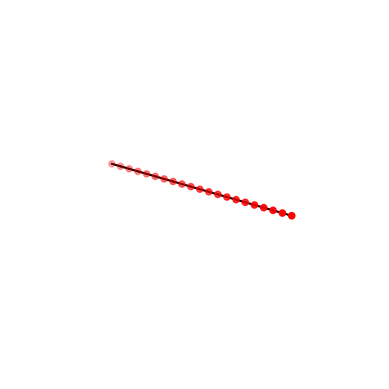

In [1]:
import numpy as np

import dismech

geom = dismech.GeomParams(rod_r0=0.001,
                          shell_h=0)

material = dismech.Material(density=1200,
                            youngs_rod=2e6,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=25,
                                  total_time=1,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2)

env = dismech.Environment()
#env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
#env.add_force('floorContact', ground_z=0, stiffness=1e3, delta=5e-3, h=1e-3)
#env.add_force('floorFriction', mu=0.75, vel_tol=1e-3)
env.add_force('rft', ct=0.01, cn=0.1)
#env.set_static()   

geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n21.txt')

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [2]:
stepper = dismech.ImplicitEulerTimeStepper(robot)

In [3]:
import numpy as np

def actuate_snake(robot, t):
    # --- Parameters you can tune ---
    amplitude = 0.2            # Max strain applied to each bend
    frequency = 1            # Oscillation frequency in Hz
    spatial_wavelength = 1.0   # Wavelength along the body in normalized units
    phase_offset = np.pi / 2   # Phase offset between vertical and tangential components

    # --- Compute strain pattern ---
    n_bends = robot.bend_springs.inc_strain.shape[0]
    s = np.linspace(0, 1, n_bends)  # Normalized position along body

    # Traveling sinusoidal waves for both vertical and tangential bending
    omega = 2 * np.pi * frequency
    k = 2 * np.pi / spatial_wavelength

    vertical_wave = amplitude * np.sin(omega * t - k * s)
    tangential_wave = amplitude * np.sin(omega * t - k * s + phase_offset)

    # Update robot bending strain (shape [n_bends, 2])
    #robot.bend_springs.inc_strain[:, 0] = vertical_wave     # normal bending
    robot.bend_springs.inc_strain[:, 1] = tangential_wave   # tangential bending

    return robot

stepper.before_step = actuate_snake
robots = stepper.simulate(robot)

qs = np.stack([robot.state.q for robot in robots])

iter: 1, error: 0.026
iter: 2, error: 1.223
iter: 3, error: 0.004
iter: 4, error: 0.004
current_time:  0.01
iter: 1, error: 0.003
iter: 2, error: 0.064
iter: 3, error: 0.000
current_time:  0.02
iter: 1, error: 0.002
iter: 2, error: 0.136
iter: 3, error: 0.000
current_time:  0.03
iter: 1, error: 0.002
iter: 2, error: 0.134
iter: 3, error: 0.000
current_time:  0.04
iter: 1, error: 0.001
iter: 2, error: 0.075
iter: 3, error: 0.000
current_time:  0.05
iter: 1, error: 0.001
iter: 2, error: 0.041
current_time:  0.06
iter: 1, error: 0.001
iter: 2, error: 0.024
current_time:  0.07
iter: 1, error: 0.001
iter: 2, error: 0.013
current_time:  0.08
iter: 1, error: 0.001
iter: 2, error: 0.008
current_time:  0.09
iter: 1, error: 0.001
iter: 2, error: 0.010
current_time:  0.1
iter: 1, error: 0.001
iter: 2, error: 0.013
current_time:  0.11
iter: 1, error: 0.001
iter: 2, error: 0.014
current_time:  0.12
iter: 1, error: 0.002
iter: 2, error: 0.013
current_time:  0.13
iter: 1, error: 0.002
iter: 2, error:

In [4]:
t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)
options = dismech.AnimationOptions(title='Snake')

fig = dismech.get_interactive_animation_plotly(robot, t, qs, options)
fig.show()

In [5]:
import numpy as np

# 1) Extract κ_ref(t) from the teacher rollout
def extract_kappa_traj_from_robots(robots, stepper):
    be = stepper.elastic_energies['bend']     # your BendEnergy
    kappas = []
    for rb in robots:
        # BendEnergy.get_strain expects RobotState
        kappa = be.get_strain(rb.state)       # shape (Nb,2)
        kappas.append(kappa.astype(np.float64))
    kappas = np.stack(kappas, axis=0)         # (T, Nb, 2)
    return kappas

# Example:
# teacher_robots = stepper.simulate(robot_teacher)
# kappa_traj = extract_kappa_traj_from_robots(teacher_robots, stepper_teacher)
# ref_times = np.arange(kappa_traj.shape[0]) * stepper_teacher.sim_params.dt
kappa_traj = extract_kappa_traj_from_robots(robots, stepper)
ref_times = np.arange(kappa_traj.shape[0]) * robot.sim_params.dt

# 2) Save κ_ref(t) and ref_times to file for later use
np.savez('snake_kappa_ref.npz', kappa_traj=kappa_traj, ref_times=ref_times)


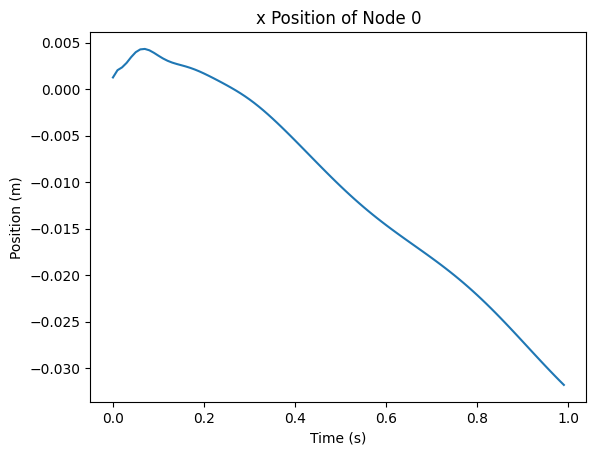

In [6]:
import matplotlib.pyplot as plt
plt.title("x Position of Node 0")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.plot(t, qs[:, 0])
plt.show()

# save the trajectory of node0 x coordinate
np.savetxt("snake_node0_trajectory.txt", qs[:, 0])